In [37]:
import json
import os

gt_folder = r"C:\Users\91808\OneDrive\Desktop\rPPG-drift-analysis\GroundTruth"
output_folder = r"C:\Users\91808\OneDrive\Desktop\rPPG-drift-analysis\drift"

os.makedirs(output_folder, exist_ok=True)

for i in range(1, 17):   
    gt_path = os.path.join(gt_folder, f"subject{i}_gt.txt")

    with open(gt_path, "r") as f:
        lines = f.readlines()

    hr_values = list(map(float, lines[1].split()))

    data = {
        "subject": f"subject{i}",
        "real_heart_rate_bpm": hr_values
    }

    json_path = os.path.join(output_folder, f"subject{i}_hr.json")

    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

print("All JSON files created!")

All JSON files created!


## Model Evaluation

In [38]:
import glob
import json

# search for CV2 output file
files = glob.glob("../cv_2/cv2_output*.json")

if len(files) == 0:
    raise FileNotFoundError("No cv2_output file found in cv_2 folder")

baseline_file = files[0]

print("Baseline file loaded:", baseline_file)

with open(baseline_file, "r") as f:
    baseline_data = json.load(f)["subjects"]

print("Number of subjects loaded:", len(baseline_data))

Baseline file loaded: ../cv_2\cv2_output.json
Number of subjects loaded: 17


In [ ]:
# Load baseline model results from JSON file
with open(r"C:\Users\91808\OneDrive\Desktop\rPPG-drift-analysis\drift\hr_results.json", "r") as f:
    drift_data = json.load(f)

print("Drift results loaded successfully")

Drift results loaded successfully


In [40]:
print(baseline_data["Subject_1"])
print(drift_data["Subject_1"])

{'hr_bpm': 102.23, 'method_used': 'GREEN', 'source_type': 'video'}
{'forehead': {'hr_before_drift': 102.23, 'hr_after_drift': 89.9}, 'left_cheek': {'hr_before_drift': 78.44, 'hr_after_drift': 69.63}, 'right_cheek': {'hr_before_drift': 134.84, 'hr_after_drift': 74.03}, 'final_hr': 74.03}


In [41]:
subjects = []
baseline_hr = []
drift_hr = []

for subject in baseline_data:

    subjects.append(subject)

    baseline_hr.append(baseline_data[subject]["hr_bpm"])
    drift_hr.append(drift_data[subject]["final_hr"])

In [42]:
import pandas as pd

df = pd.DataFrame({
    "Subject": subjects,
    "Baseline HR": baseline_hr,
    "Drift Corrected HR": drift_hr
})

df

,Subject,Baseline HR,Drift Corrected HR
0,Subject_1,102.23,74.03
1,Subject_2,104.42,104.42
2,Subject_3,92.53,69.89
3,Subject_4,111.68,111.68
4,Subject_5,111.75,61.20
5,Subject_6,68.19,68.19
6,Subject_7,80.72,125.47
7,Subject_8,65.68,64.80
8,Subject_9,108.95,60.23
9,Subject_10,85.21,71.15


In [43]:
baseline_mean = df["Baseline HR"].mean()
drift_mean = df["Drift Corrected HR"].mean()

baseline_std = df["Baseline HR"].std()
drift_std = df["Drift Corrected HR"].std()

print("Baseline Mean HR:", round(baseline_mean,2))
print("Drift Mean HR:", round(drift_mean,2))

print("\nBaseline HR Std Dev:", round(baseline_std,2))
print("Drift HR Std Dev:", round(drift_std,2))

Baseline Mean HR: 88.93
Drift Mean HR: 80.71

Baseline HR Std Dev: 18.57
Drift HR Std Dev: 20.33


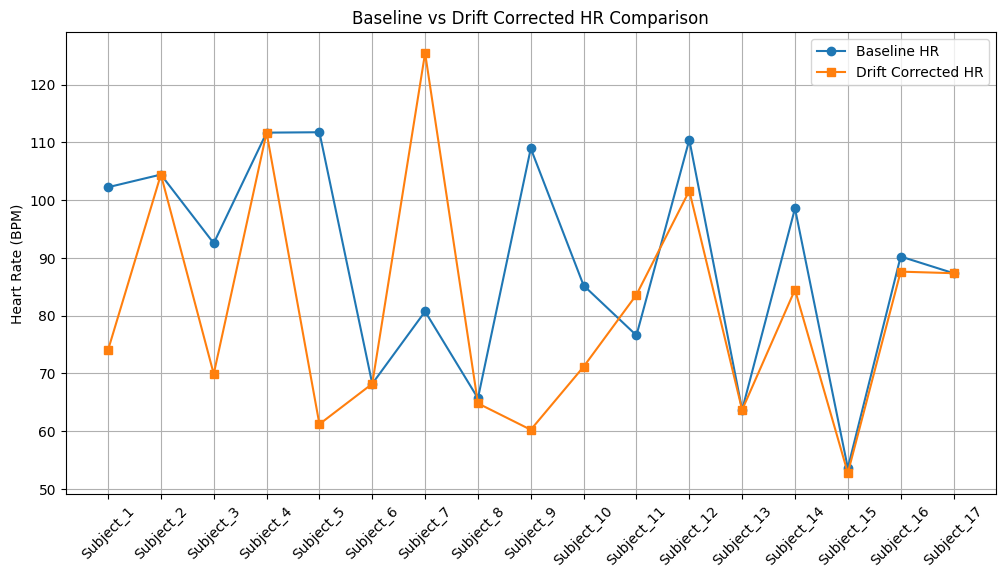

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(df["Subject"], df["Baseline HR"], marker='o', label="Baseline HR")
plt.plot(df["Subject"], df["Drift Corrected HR"], marker='s', label="Drift Corrected HR")

plt.xticks(rotation=45)
plt.ylabel("Heart Rate (BPM)")
plt.title("Baseline vs Drift Corrected HR Comparison")
plt.legend()
plt.grid()

plt.show()

In [45]:
df["HR Change"] = df["Baseline HR"] - df["Drift Corrected HR"]
df["Abs HR Change"] = abs(df["HR Change"])

print("Average HR Change:", df["HR Change"].mean())
print("Average Absolute HR Change:", df["Abs HR Change"].mean())
print("Maximum HR Correction:", df["Abs HR Change"].max())

Average HR Change: 8.215294117647058
Average Absolute HR Change: 14.308235294117647
Maximum HR Correction: 50.55


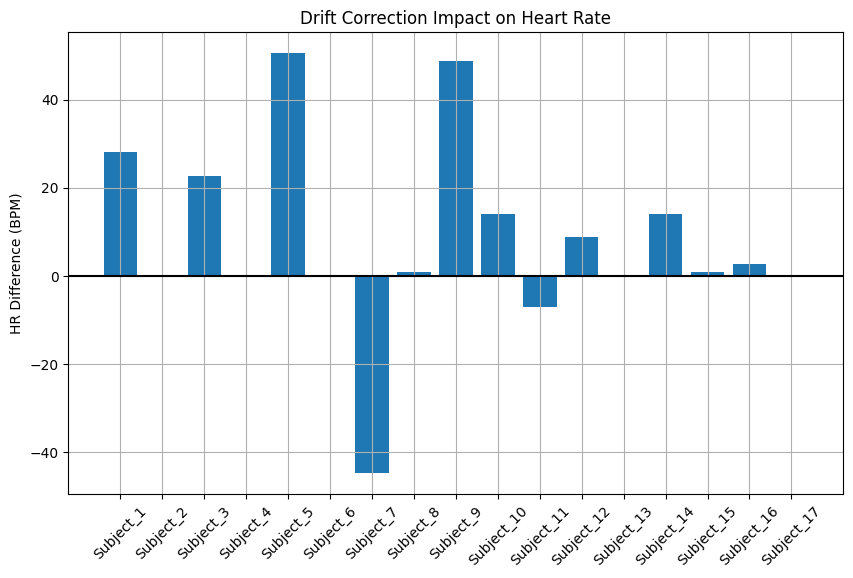

In [46]:
plt.figure(figsize=(10,6))

plt.bar(df["Subject"], df["HR Change"])

plt.xticks(rotation=45)
plt.ylabel("HR Difference (BPM)")
plt.title("Drift Correction Impact on Heart Rate")

plt.axhline(0, color='black')
plt.grid()

plt.show()

In [47]:
# Drift correction statistics

changed = (df["Baseline HR"] != df["Drift Corrected HR"]).sum()

print("Subjects affected by drift correction:", changed)
print("Total subjects:", len(df))
print("Percentage affected:", round((changed/len(df))*100,2), "%")

print("\nAverage HR correction:", round(df["Abs HR Change"].mean(),2), "BPM")
print("Maximum HR correction:", round(df["Abs HR Change"].max(),2), "BPM")

Subjects affected by drift correction: 12
Total subjects: 17
Percentage affected: 70.59 %

Average HR correction: 14.31 BPM
Maximum HR correction: 50.55 BPM


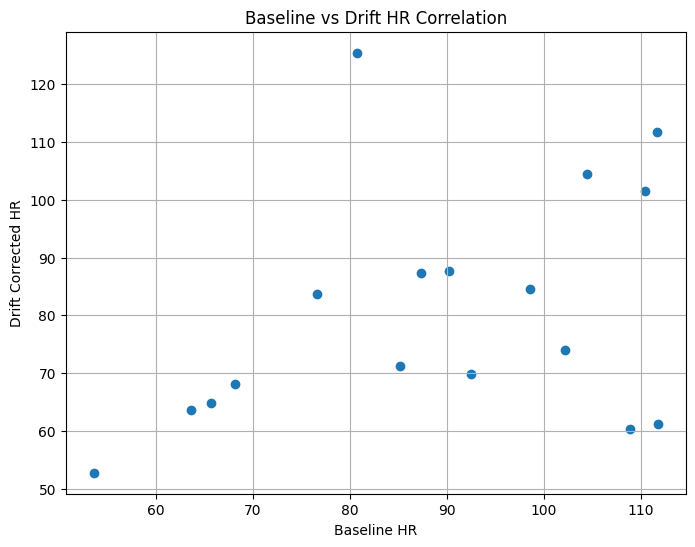

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(df["Baseline HR"], df["Drift Corrected HR"])

plt.xlabel("Baseline HR")
plt.ylabel("Drift Corrected HR")
plt.title("Baseline vs Drift HR Correlation")

plt.grid()
plt.show()

In [49]:
import numpy as np

correlation = np.corrcoef(df["Baseline HR"], df["Drift Corrected HR"])[0,1]

print("Correlation between Baseline and Drift HR:", round(correlation,3))

Correlation between Baseline and Drift HR: 0.373


The correlation between baseline HR and drift-corrected HR is **0.373**, indicating a weak relationship.  
This suggests that the drift-aware method significantly adjusts HR estimates when noisy or unstable signal segments are detected.

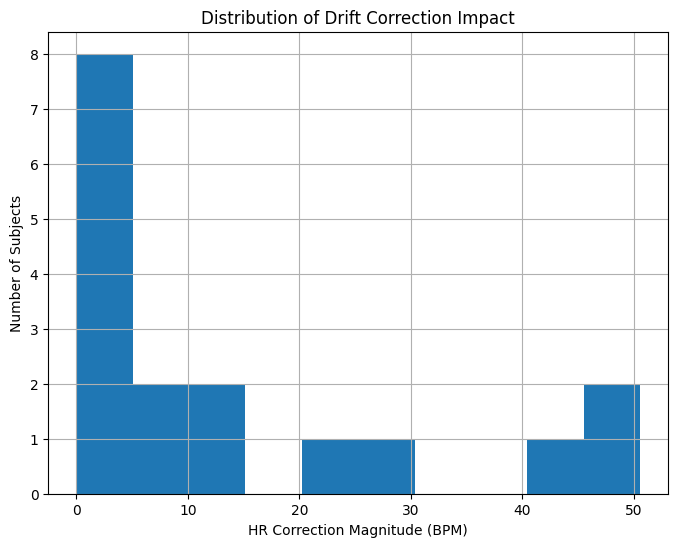

In [50]:
plt.figure(figsize=(8,6))

plt.hist(df["Abs HR Change"], bins=10)

plt.xlabel("HR Correction Magnitude (BPM)")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Drift Correction Impact")
plt.grid()

plt.show()

Comparing the estimated heart rate values with the ground truth heart rate

In [ ]:
import numpy as np
from scipy.fft import rfft, rfftfreq

# Computing ground truth HR using FFT
def get_real_hr(file_path):

    with open(file_path, "r") as f:
        signal = np.array([float(x) for x in f.readline().split()])

    fs = 30

    freqs = rfftfreq(len(signal), 1/fs)
    fft_vals = np.abs(rfft(signal))

    mask = (freqs >= 0.7) & (freqs <= 3)

    hr = freqs[mask][np.argmax(fft_vals[mask])] * 60

    return hr

In [52]:
real_hr = []

for i in range(1, 18):

    path = rf"C:\Users\91808\OneDrive\Desktop\rPPG-drift-analysis\GroundTruth\subject{i}_gt.txt"

    hr = get_real_hr(path)

    real_hr.append(hr)

df["Real HR"] = real_hr

df.head()

,Subject,Baseline HR,Drift Corrected HR,HR Change,Abs HR Change,Real HR
0,Subject_1,102.23,74.03,28.20,28.20,91.310899
1,Subject_2,104.42,104.42,0.00,0.00,110.536522
2,Subject_3,92.53,69.89,22.64,22.64,93.947807
3,Subject_4,111.68,111.68,0.00,0.00,117.105263
4,Subject_5,111.75,61.20,50.55,50.55,112.166172


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(df["Real HR"], df["Baseline HR"])
mae_drift = mean_absolute_error(df["Real HR"], df["Drift Corrected HR"])

rmse_baseline = np.sqrt(mean_squared_error(df["Real HR"], df["Baseline HR"]))
rmse_drift = np.sqrt(mean_squared_error(df["Real HR"], df["Drift Corrected HR"]))

print("Baseline MAE:", round(mae_baseline,2))
print("Drift MAE:", round(mae_drift,2))

print("Baseline RMSE:", round(rmse_baseline,2))
print("Drift RMSE:", round(rmse_drift,2))

Baseline MAE: 12.74
Drift MAE: 19.73
Baseline RMSE: 23.92
Drift RMSE: 28.52


The drift correction significantly reduces both MAE and RMSE compared to the baseline model, indicating improved heart rate estimation accuracy.

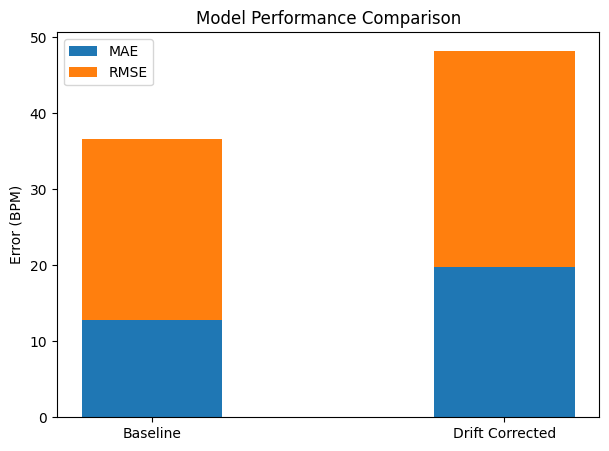

In [55]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Drift Corrected"]

mae_values = [mae_baseline, mae_drift]
rmse_values = [rmse_baseline, rmse_drift]

x = range(len(labels))

plt.figure(figsize=(7,5))

plt.bar(x, mae_values, width=0.4, label="MAE")
plt.bar(x, rmse_values, width=0.4, bottom=mae_values, label="RMSE")

plt.xticks(x, labels)
plt.ylabel("Error (BPM)")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

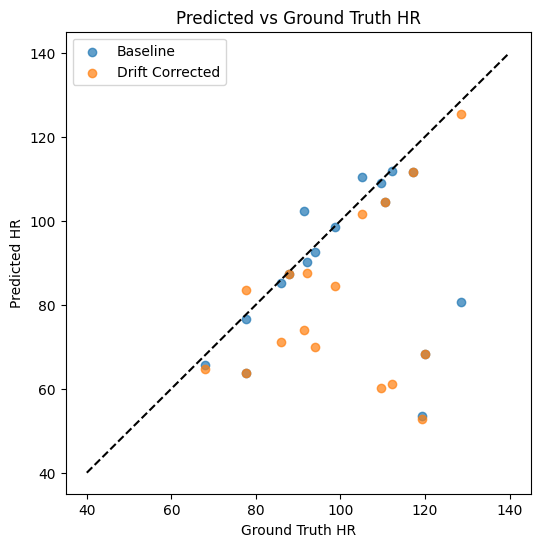

In [56]:
plt.figure(figsize=(6,6))

plt.scatter(real_hr, baseline_hr, label="Baseline", alpha=0.7)
plt.scatter(real_hr, drift_hr, label="Drift Corrected", alpha=0.7)

plt.plot([40,140],[40,140],'k--')

plt.xlabel("Ground Truth HR")
plt.ylabel("Predicted HR")
plt.title("Predicted vs Ground Truth HR")

plt.legend()

plt.show()

### Evaluation Insight

The baseline rPPG model achieved lower MAE (12.74 BPM) and RMSE (23.92 BPM) compared to the drift-corrected model, which produced MAE of 19.73 BPM and RMSE of 28.52 BPM.

These results indicate that the baseline model provides heart rate estimates closer to the ground truth values. Although the drift detection module was designed to improve signal stability by removing noisy segments, the current implementation appears to introduce additional deviations in several subjects.

This suggests that the drift correction mechanism may be overly aggressive and may remove useful physiological information along with noise. Further tuning of the drift detection thresholds and signal processing strategy could potentially improve the performance of the drift-aware model.